In [1]:
import numpy as np
import scanpy as sc

## Liver dataset

In [2]:
adata = sc.read_h5ad(
    "/home/ubuntu/data/dataset-similarity/raw/bb930137-be57-42f1-9a86-dc69370404e8.h5ad",
)

In [3]:
adata_raw = adata.raw.to_adata()
del adata.raw

In [4]:
adata

AnnData object with n_obs × n_vars = 11127 × 33363
    obs: 'mapped_reference_assembly', 'mapped_reference_annotation', 'alignment_software', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'organism_ontology_term_id', 'sample_uuid', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_derivation_process', 'tissue_type', 'suspension_depleted_cell_types', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_dissociation_time', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_uuid', 'assay_ontology_term_id', 'library_starting_quantity', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'sex_ontology_term_id', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'Phase', 'Coarse_clusters', 'sample', 'cell_type', 'assay', 'disease', 'organism', 'se

In [5]:
adata.var.index = adata.var.feature_name.str.split("_").str[0]
adata_raw.var.index = adata_raw.var.feature_name.str.split("_").str[0]

In [6]:
adata = adata[:, ~adata.var.index.duplicated()]
adata_raw = adata_raw[:, ~adata_raw.var.index.duplicated()]

/vol/data/miniconda3/envs/pseudobulk/lib/python3.10/site-packages/scanpy/plotting/_utils.py:471: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


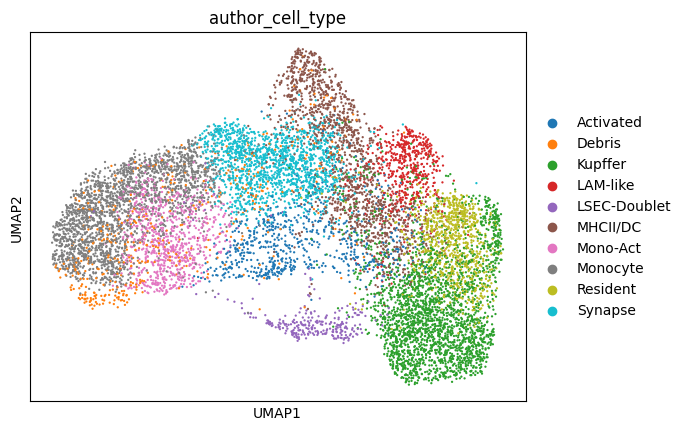

In [7]:
sc.pl.umap(adata, color="author_cell_type")

In [9]:
%load_ext autoreload

In [10]:
%autoreload
from sconnect.de_testing.testing import calc_pseudobulk_stats
from sconnect.de_testing.selection import (
    select_and_combine_de_results,
    sort_and_filter_de_genes_ova,
    sort_and_filter_de_genes_ava,
)

In [11]:
de_res_ova, de_res_ava = calc_pseudobulk_stats(
    adata_raw,
    cluster_label="author_cell_type",
    sample_label="sample"
)

/vol/data/git/dataset-similarity/datasim/de_testing/testing.py:272: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[cluster_label] = (
R[write to console]: data.table 1.15.4 using 8 threads (see ?getDTthreads).  
R[write to console]: Latest news: r-datatable.com

Calculating AVA AUROC scores: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [01:27<00:00,  1.95s/it]


In [12]:
res = select_and_combine_de_results(
    sort_and_filter_de_genes_ova(
        de_res_ova,
        logfc_threshold=0.0,
        aucroc_threshold=0.5,
        adj_pval_threshold=0.05
    ),
    sort_and_filter_de_genes_ava(
        de_res_ava,
        logfc_threshold=0.0,
        aucroc_threshold=0.5,
        adj_pval_threshold=0.05
    ),
    overlap_threshold=0.3,
    n_genes_ova=None,
    n_genes_ava=None
)

In [13]:
from IPython.display import display

In [14]:
for cluster in np.unique(adata_raw.obs.author_cell_type):
    df = res[cluster]
    df = df.head(15)
    print(cluster)
    display(
        df.style
        .format("{:.2f}", subset=["logFC", "auroc"])
        .format("{:.3f}", subset=["adj.P.Val"])
    )
    print()

Activated


,logFC,adj.P.Val,auroc,reference
ID,,,,
AREG,2.19,0.000,0.76,['all']
CXCL3,2.02,0.000,0.67,['all']
CCL4,1.79,0.000,0.61,['all']
PLAUR,1.75,0.000,0.78,['all']
THBS1,1.72,0.000,0.72,['all']
CXCL8,1.69,0.000,0.62,['all']
IL1B,1.65,0.000,0.63,['all']
EREG,1.65,0.000,0.61,['all']
CD83,1.62,0.000,0.69,['all']



Debris


,logFC,adj.P.Val,auroc,reference
ID,,,,
ECHDC2,1.22,0.000,0.64,['all']
ORM2,1.20,0.000,0.70,['all']
MST1,1.16,0.000,0.64,['all']
ACSM2A,1.09,0.000,0.65,['all']
C1S,1.06,0.001,0.70,['all']
AZGP1,1.05,0.000,0.70,['all']
ACSM2B,1.03,0.001,0.67,['all']
SLC39A14,1.02,0.000,0.62,['all']
ITIH3,1.02,0.002,0.66,['all']



Kupffer


...

,logFC,adj.P.Val,auroc,reference
S100A12,3.27,0.000,0.83,['all']
S100A8,3.04,0.000,0.90,['all']
VCAN,2.51,0.000,0.81,['all']
S100A9,2.32,0.000,0.88,['all']
FCN1,2.13,0.000,0.73,['all']
MNDA,1.90,0.000,0.72,['all']
RETN,1.75,0.000,0.59,['all']
RNASE2,1.62,0.000,0.64,['all']
PLP2,1.61,0.000,0.62,['all']
SELL,1.58,0.000,0.60,['all']



Resident


,logFC,adj.P.Val,auroc,reference
CD5L,2.80,0.000,0.82,['all']
MARCO,2.69,0.000,0.85,['all']
VCAM1,2.58,0.000,0.78,['all']
C1QB,2.34,0.000,0.91,"['all', 'Kupffer']"
FOLR2,2.29,0.000,0.81,"['all', 'Kupffer']"
PLTP,2.25,0.000,0.77,['all']
TIMD4,2.21,0.000,0.67,"['all', 'Kupffer']"
SLC40A1,2.05,0.000,0.83,['all']
LYVE1,2.04,0.000,0.76,['all']
C1QC,2.03,0.000,0.85,"['all', 'Kupffer']"



Synapse


,logFC,adj.P.Val,auroc,reference
ID,,,,
CD48,1.00,0.009,0.61,['all']
CD52,1.00,0.015,0.67,['all']
C19orf38,0.95,0.002,0.56,['all']
CORO1A,0.91,0.019,0.63,['all']
ADISSP,0.88,0.003,0.57,['all']
CD300E,0.88,0.033,0.59,['all']
ABI3,0.84,0.004,0.58,['all']
JAML,0.82,0.019,0.57,['all']
CALHM6,0.82,0.031,0.56,['all']


In [56]:
markers = ["CCL3", "CCL4", "AREG", "CD83", "CXCL2", "CXCL3", "IL1B", "NAMPT", "PLAUR", "SRGN", "THBS1"]


for cluster in np.unique(adata_raw.obs.author_cell_type):
    df = res[cluster]
    df.index.name = "ID"
    print(cluster)
    display(
        df
        .reset_index()
        .query(f'`ID` in {markers}')
        .style
        .format("{:.2f}", subset=["logFC", "auroc"])
        .format("{:.3f}", subset=["adj.P.Val"])
    )
    print()


Activated


,ID,logFC,adj.P.Val,auroc,reference
0,AREG,2.19,0.000,0.76,['all']
1,CXCL3,2.02,0.000,0.67,['all']
2,CCL4,1.79,0.000,0.61,['all']
3,PLAUR,1.75,0.000,0.78,['all']
4,THBS1,1.72,0.000,0.72,['all']
6,IL1B,1.65,0.000,0.63,['all']
8,CD83,1.62,0.000,0.69,['all']
10,CCL3,1.56,0.000,0.64,['all']
11,CXCL2,1.51,0.000,0.69,['all']
44,NAMPT,0.95,0.000,0.74,['all']



Debris


,ID,logFC,adj.P.Val,auroc,reference



Kupffer


...

,ID,logFC,adj.P.Val,auroc,reference



Resident


,ID,logFC,adj.P.Val,auroc,reference
73,CCL4,1.01,0.027,0.54,['all']



Synapse


,ID,logFC,adj.P.Val,auroc,reference
